In [2]:
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
  sys.path.append(str(dir))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import yfinance as yf
import math
from utils import log_transform
import torch
import joblib
from utils import one_step_rolling_forecast
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

In [4]:
ticker = "^GSPC"
start_interval = "2010-01-01"
end_interval = "2026-01-01"
interval = "1d" 

raw_snp500 = yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy()
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split

train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

train_snp500 = log_transform(train_raw_snp500)
test_snp500 = log_transform(test_raw_snp500)

In [5]:
DATA_DIR = dir / "data"
SYN_PATH_128 = DATA_DIR / "syn_data_128.joblib"
SYN_PATH_256 = DATA_DIR / "syn_data_256.joblib"
SYN_PATH_512 = DATA_DIR / "syn_data_512.joblib"

SYN_STD_PRED_128 = DATA_DIR / "syn_std_pred_128.joblib"
SYN_STD_PRED_256 = DATA_DIR / "syn_std_pred_256.joblib"
SYN_STD_PRED_512 = DATA_DIR / "syn_std_pred_512.joblib"

MC_STD_PRED_128 = DATA_DIR / "mc_std_pred_128.joblib"
MC_STD_PRED_256 = DATA_DIR / "mc_std_pred_256.joblib"
MC_STD_PRED_512 = DATA_DIR / "mc_std_pred_512.joblib"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

### If data already exists

In [6]:
syn_pred_std_128 = joblib.load(SYN_STD_PRED_128)
syn_pred_std_256 = joblib.load(SYN_STD_PRED_256)
syn_pred_std_512 = joblib.load(SYN_STD_PRED_512)

mc_std_pred_128 = joblib.load(MC_STD_PRED_128)
mc_std_pred_256 = joblib.load(MC_STD_PRED_256)
mc_std_pred_512 = joblib.load(MC_STD_PRED_512)

In [7]:
mc_preds_128_flattened = mc_std_pred_128["preds"].reshape(-1)
mc_preds_256_flattened = mc_std_pred_256["preds"].reshape(-1)
mc_preds_512_flattened = mc_std_pred_512["preds"].reshape(-1)

syn_preds_128_flattened = syn_pred_std_128["preds"].reshape(-1)
syn_preds_256_flattened = syn_pred_std_256["preds"].reshape(-1)
syn_preds_512_flattened = syn_pred_std_512["preds"].reshape(-1)

In [7]:
synthetic_data_128 = joblib.load(SYN_PATH_128)
synthetic_data_256 = joblib.load(SYN_PATH_256)
synthetic_data_512 = joblib.load(SYN_PATH_512)

synthetic_data_128.shape, synthetic_data_256.shape, synthetic_data_512.shape

((1000, 128), (1000, 256), (1000, 512))

### DDPM Simulation Testing

In [9]:
latest_emp_window_128 = train_snp500[-128:]
test_window_128 = test_snp500[:128]

latest_emp_window_256 = train_snp500[-256:]
test_window_256 = test_snp500[:256]

latest_emp_window_512 = train_snp500[-512:]
test_window_512 = test_snp500[:512]

In [10]:
# 128-window
syn_preds_windows_128 = []
syn_losses_windows_128 = []

for syn_window in synthetic_data_128[:100]:
  syn_preds, losses = one_step_rolling_forecast(latest_emp_window_128 * 100, syn_window * 100) # scaling for stabilization in GARCH fitting
  syn_preds_windows_128.append(syn_preds)
  syn_losses_windows_128.append(losses)

D:\CodingHenry\research_MBKM\utils\utils.py:86: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp="off")


In [11]:
emp_preds_128, emp_losses_128 = one_step_rolling_forecast(latest_emp_window_128 * 100, test_window_128 * 100)

In [12]:
emp_preds_128 = np.array(emp_preds_128) / 100

In [13]:
# scaled back
syn_preds_windows_128 = np.array(syn_preds_windows_128) / 100

In [14]:
sim_pred_128 = {
  "preds": syn_preds_windows_128,
  "losses": syn_losses_windows_128
}

joblib.dump(sim_pred_128, SYN_STD_PRED_128)

['D:\\CodingHenry\\research_MBKM\\data\\syn_std_pred_128.joblib']

In [15]:
# 256-window
syn_preds_windows_256 = []
syn_losses_windows_256 = []

for syn_window in synthetic_data_256[:100]:
  syn_preds, losses = one_step_rolling_forecast(latest_emp_window_256 * 100, syn_window * 100) # scaling for stabilization in GARCH fitting
  syn_preds_windows_256.append(syn_preds)
  syn_losses_windows_256.append(losses)

In [16]:
emp_preds_256, emp_losses_256 = one_step_rolling_forecast(latest_emp_window_256 * 100, test_window_256 * 100)
emp_preds_256 = np.array(emp_preds_256) / 100

In [17]:
# scaled back
syn_preds_windows_256 = np.array(syn_preds_windows_256) / 100

In [18]:
sim_pred_256 = {
  "preds": syn_preds_windows_256,
  "losses": syn_losses_windows_256
}

joblib.dump(sim_pred_256, SYN_STD_PRED_256)

['D:\\CodingHenry\\research_MBKM\\data\\syn_std_pred_256.joblib']

In [19]:
# 512-window
syn_preds_windows_512 = []
syn_losses_windows_512 = []

for syn_window in synthetic_data_512[:100]:
  syn_preds, losses = one_step_rolling_forecast(latest_emp_window_512 * 100, syn_window * 100) # scaling for stabilization in GARCH fitting
  syn_preds_windows_512.append(syn_preds)
  syn_losses_windows_512.append(losses)

In [20]:
emp_preds_512, emp_losses_512 = one_step_rolling_forecast(latest_emp_window_512 * 100, test_window_512 * 100)
emp_preds_512 = np.array(emp_preds_512) / 100

In [21]:
# scaled back
syn_preds_windows_512 = np.array(syn_preds_windows_512) / 100

In [22]:
sim_pred_512 = {
  "preds": syn_preds_windows_512,
  "losses": syn_losses_windows_512
}

joblib.dump(sim_pred_512, SYN_STD_PRED_512)

['D:\\CodingHenry\\research_MBKM\\data\\syn_std_pred_512.joblib']

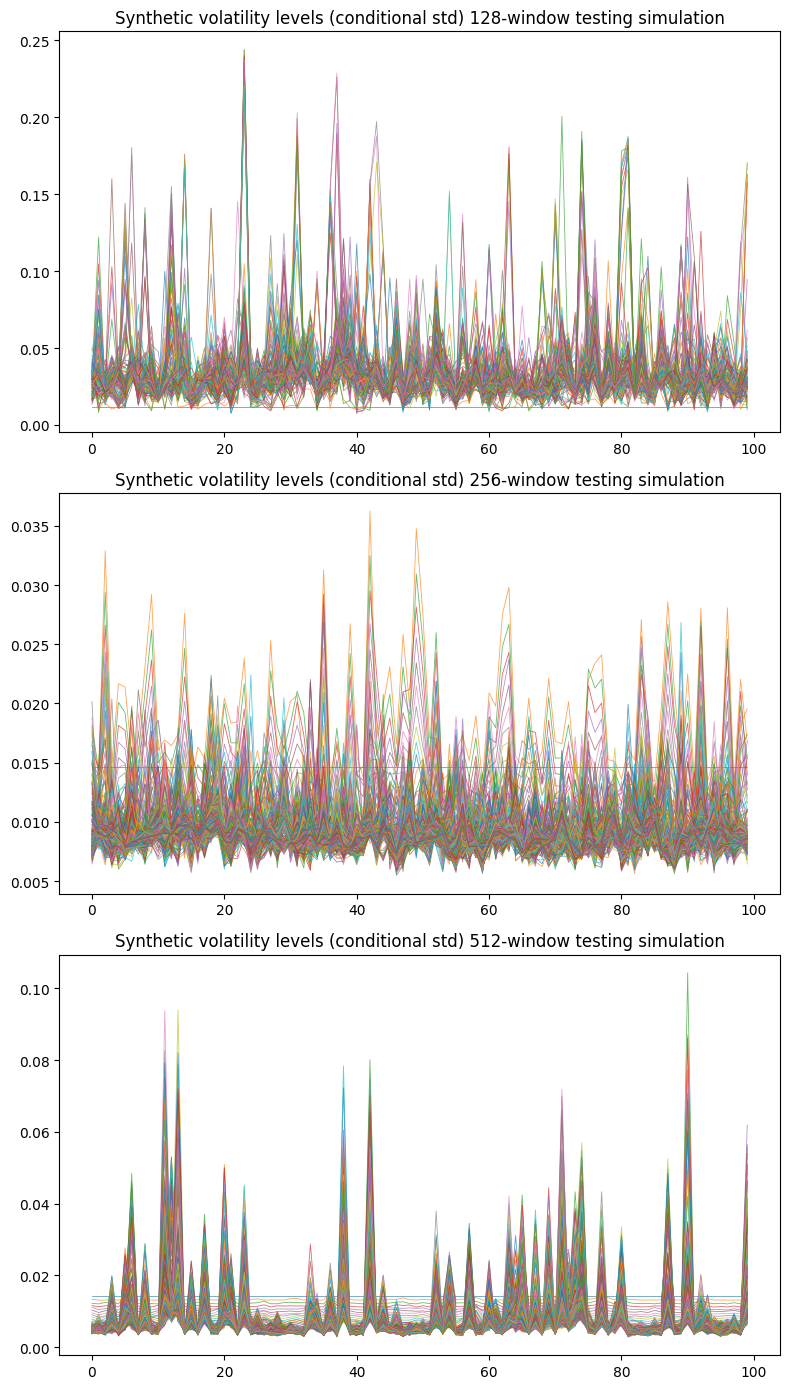

In [23]:
fig, ax = plt.subplots(3, figsize=(8,14))

ax[0].set_title("Synthetic volatility levels (conditional std) 128-window testing simulation")
ax[1].set_title("Synthetic volatility levels (conditional std) 256-window testing simulation")
ax[2].set_title("Synthetic volatility levels (conditional std) 512-window testing simulation")

ax[0].plot(syn_preds_windows_128, linewidth=0.6, alpha=0.7)
ax[1].plot(syn_preds_windows_256, linewidth=0.6, alpha=0.7)
ax[2].plot(syn_preds_windows_512, linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()

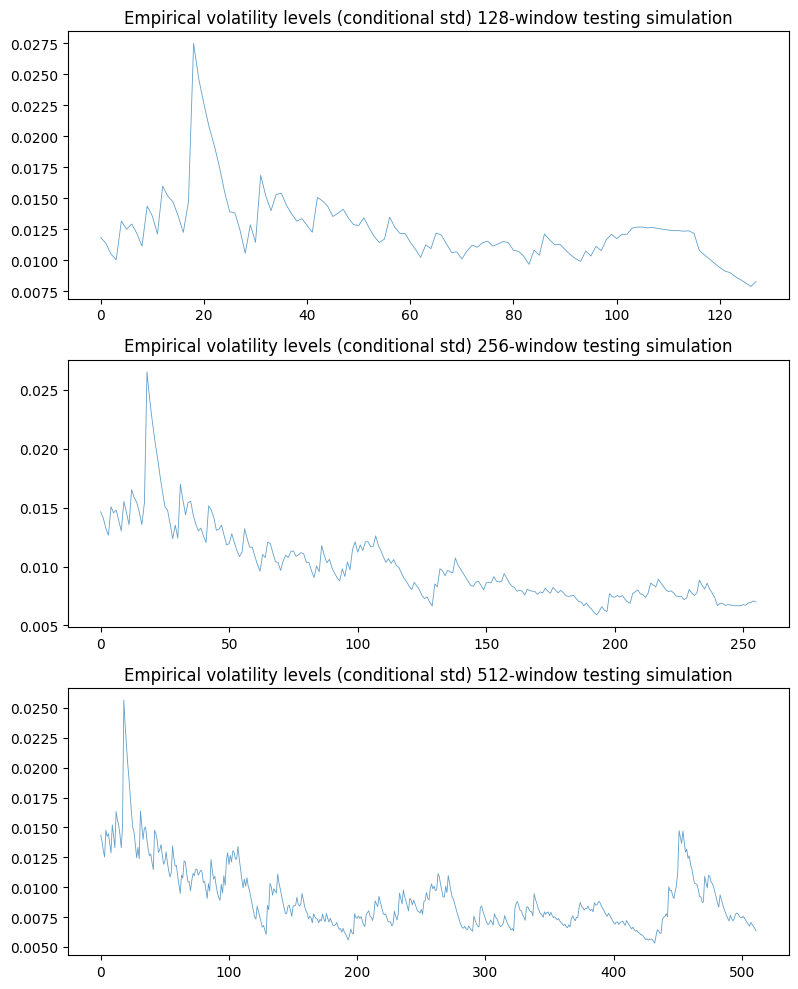

In [24]:
fig, ax = plt.subplots(3, figsize=(8,10))

ax[0].set_title("Empirical volatility levels (conditional std) 128-window testing simulation")
ax[1].set_title("Empirical volatility levels (conditional std) 256-window testing simulation")
ax[2].set_title("Empirical volatility levels (conditional std) 512-window testing simulation")

ax[0].plot(emp_preds_128, linewidth=0.6, alpha=0.7)
ax[1].plot(emp_preds_256, linewidth=0.6, alpha=0.7)
ax[2].plot(emp_preds_512, linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()

In [25]:
res_mc = arch_model(train_snp500 * 100, vol="Garch", p=1, q=1, dist="t").fit(disp="off")

In [26]:
# monte carlo sim
sim_paths_128 = []
sim_paths_256 = []
sim_paths_512 = []
PATHS = 100

for _ in range(PATHS):
  sim_128 = res_mc.model.simulate(res_mc.params, nobs=128)
  sim_256 = res_mc.model.simulate(res_mc.params, nobs=256)
  sim_512 = res_mc.model.simulate(res_mc.params, nobs=512)

  sim_paths_128.append(sim_128["data"].values)
  sim_paths_256.append(sim_256["data"].values)
  sim_paths_512.append(sim_512["data"].values)

In [27]:
mc_preds_128 = []
mc_losses_128 = []
 
for i in range(PATHS):
  fake_test = sim_paths_128[i] # still scaled
  preds, losses = one_step_rolling_forecast(latest_emp_window_128 * 100, fake_test)
  mc_preds_128.append(preds)
  mc_losses_128.append(losses)

In [28]:
mc_preds_128 = np.array(mc_preds_128) / 100

In [29]:
mc_pred_128 = {
  "preds":  mc_preds_128,
  "losses": mc_losses_128
}

joblib.dump(mc_pred_128, MC_STD_PRED_128)

['D:\\CodingHenry\\research_MBKM\\data\\mc_std_pred_128.joblib']

In [30]:
mc_preds_256 = []
mc_losses_256 = []

for i in range(PATHS):
  fake_test = sim_paths_256[i]
  preds, losses = one_step_rolling_forecast(latest_emp_window_256 * 100, fake_test)
  mc_preds_256.append(preds)
  mc_losses_256.append(losses)

mc_preds_128 = np.array(mc_preds_128) / 100

In [31]:
mc_preds_256 = np.array(mc_preds_256) / 100

In [32]:
mc_pred_256 = {
  "preds":  mc_preds_256,
  "losses": mc_losses_256
}

joblib.dump(mc_pred_256, MC_STD_PRED_256)

['D:\\CodingHenry\\research_MBKM\\data\\mc_std_pred_256.joblib']

In [33]:
mc_preds_512 = []
mc_losses_512 = []

for i in range(PATHS):
  fake_test = sim_paths_512[i]
  preds, losses = one_step_rolling_forecast(latest_emp_window_512 * 100, fake_test)
  mc_preds_512.append(preds)
  mc_losses_512.append(losses)

In [34]:
mc_preds_512 = np.array(mc_preds_512) / 100

In [35]:
mc_pred_512 = {
  "preds":  mc_preds_512,
  "losses": mc_losses_512
}

joblib.dump(mc_pred_512, MC_STD_PRED_512)

['D:\\CodingHenry\\research_MBKM\\data\\mc_std_pred_512.joblib']

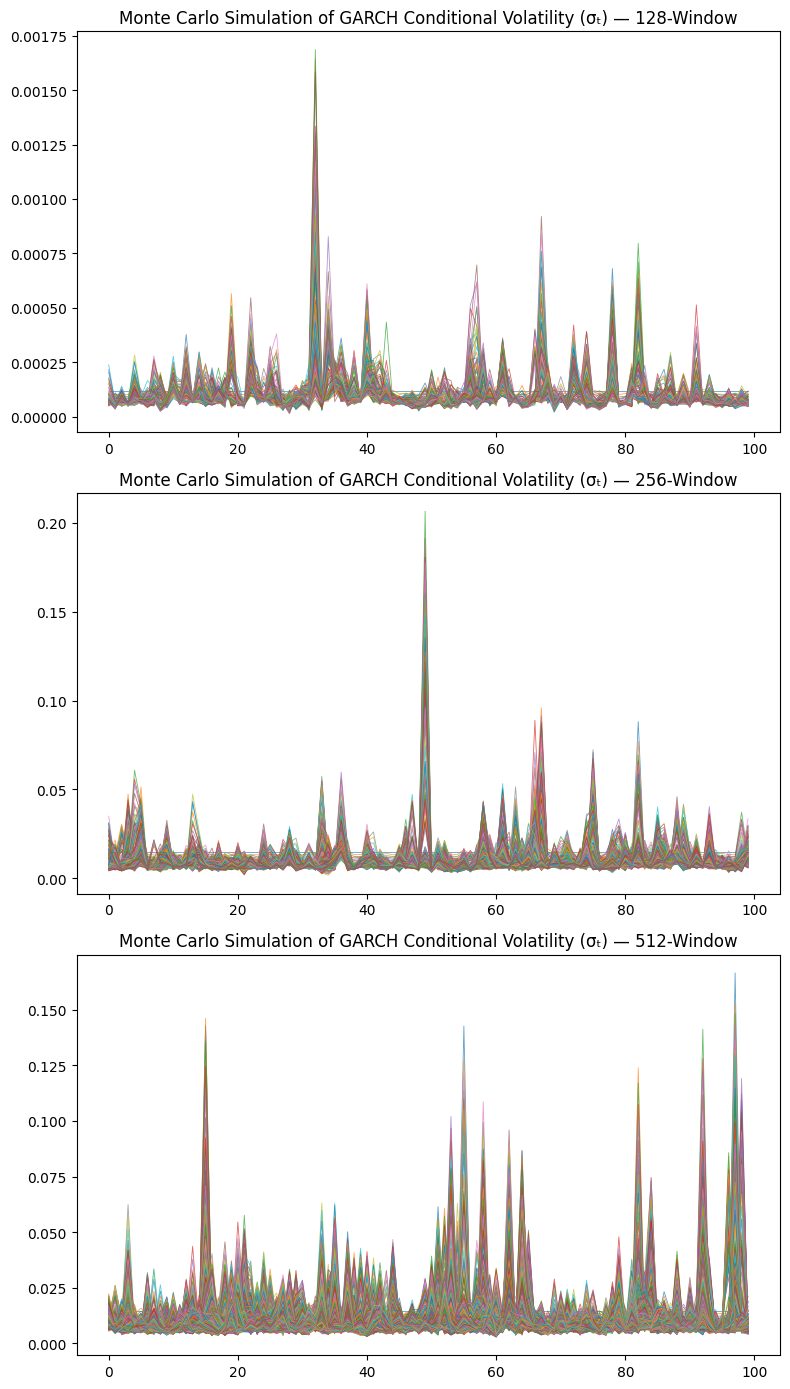

In [36]:
fig, ax = plt.subplots(3, figsize=(8,14))

ax[0].set_title("Monte Carlo Simulation of GARCH Conditional Volatility (σₜ) — 128-Window")
ax[1].set_title("Monte Carlo Simulation of GARCH Conditional Volatility (σₜ) — 256-Window")
ax[2].set_title("Monte Carlo Simulation of GARCH Conditional Volatility (σₜ) — 512-Window")

ax[0].plot(mc_preds_128, linewidth=0.6, alpha=0.7)
ax[1].plot(mc_preds_256, linewidth=0.6, alpha=0.7)
ax[2].plot(mc_preds_512, linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()

### Loss evaluation

In [37]:
emp_losses_128 = np.array(emp_losses_128)
emp_losses_256 = np.array(emp_losses_256)
emp_losses_512 = np.array(emp_losses_512)

syn_losses_windows_128 = np.array(syn_losses_windows_128)
syn_losses_windows_256 = np.array(syn_losses_windows_256)
syn_losses_windows_512 = np.array(syn_losses_windows_512)

mc_losses_128 = np.array(mc_losses_128)
mc_losses_256 = np.array(mc_losses_256)
mc_losses_512 = np.array(mc_losses_512)

print("QLIKE LOSS EVALUATION")
print("Empirical Losses:")
print(f"128 -> mean: {emp_losses_128.mean():.3f}, std: {emp_losses_128.std():.3f}, min: {emp_losses_128.min():.3f}, max: {emp_losses_128.max():.3f}, median: {np.median(emp_losses_128):.3f}")
print(f"256 -> mean: {emp_losses_256.mean():.3f}, std: {emp_losses_256.std():.3f}, min: {emp_losses_256.min():.3f}, max: {emp_losses_256.max():.3f}, median: {np.median(emp_losses_256):.3f}")
print(f"512 -> mean: {emp_losses_512.mean():.3f}, std: {emp_losses_512.std():.3f}, min: {emp_losses_512.min():.3f}, max: {emp_losses_512.max():.3f}, median: {np.median(emp_losses_512):.3f}")

print("\nSynthetic Losses:")
print(f"128 -> mean: {syn_losses_windows_128.mean():.3f}, std: {syn_losses_windows_128.std():.3f}, min: {syn_losses_windows_128.min():.3f}, max: {syn_losses_windows_128.max():.3f}, median: {np.median(syn_losses_windows_128):.3f}")
print(f"256 -> mean: {syn_losses_windows_256.mean():.3f}, std: {syn_losses_windows_256.std():.3f}, min: {syn_losses_windows_256.min():.3f}, max: {syn_losses_windows_256.max():.3f}, median: {np.median(syn_losses_windows_256):.3f}")
print(f"512 -> mean: {syn_losses_windows_512.mean():.3f}, std: {syn_losses_windows_512.std():.3f}, min: {syn_losses_windows_512.min():.3f}, max: {syn_losses_windows_512.max():.3f}, median: {np.median(syn_losses_windows_512):.3f}")

print("\nMonte Carlo Losses:")
print(f"128 -> mean: {mc_losses_128.mean():.3f}, std: {mc_losses_128.std():.3f}, min: {mc_losses_128.min():.3f}, max: {mc_losses_128.max():.3f}, median: {np.median(mc_losses_128):.3f}")
print(f"256 -> mean: {mc_losses_256.mean():.3f}, std: {mc_losses_256.std():.3f}, min: {mc_losses_256.min():.3f}, max: {mc_losses_256.max():.3f}, median: {np.median(mc_losses_256):.3f}")
print(f"512 -> mean: {mc_losses_512.mean():.3f}, std: {mc_losses_512.std():.3f}, min: {mc_losses_512.min():.3f}, max: {mc_losses_512.max():.3f}, median: {np.median(mc_losses_512):.3f}")

QLIKE LOSS EVALUATION
Empirical Losses:
128 -> mean: 1.361, std: 1.654, min: -0.401, max: 14.186, median: 0.955
256 -> mean: 0.896, std: 1.471, min: -0.990, max: 13.149, median: 0.525
512 -> mean: 0.670, std: 1.484, min: -1.181, max: 13.526, median: 0.268

Synthetic Losses:
128 -> mean: 3.763, std: 5.417, min: -0.285, max: 277.640, median: 2.868
256 -> mean: 0.895, std: 2.736, min: -1.073, max: 93.121, median: 0.282
512 -> mean: -0.125, std: 2.091, min: -2.458, max: 120.945, median: -0.600

Monte Carlo Losses:
128 -> mean: 0.820, std: 3.447, min: -3.074, max: 204.447, median: 0.147
256 -> mean: 0.704, std: 2.808, min: -2.585, max: 118.782, median: 0.111
512 -> mean: 0.735, std: 2.739, min: -2.398, max: 163.886, median: 0.128


### Distribution Comparison

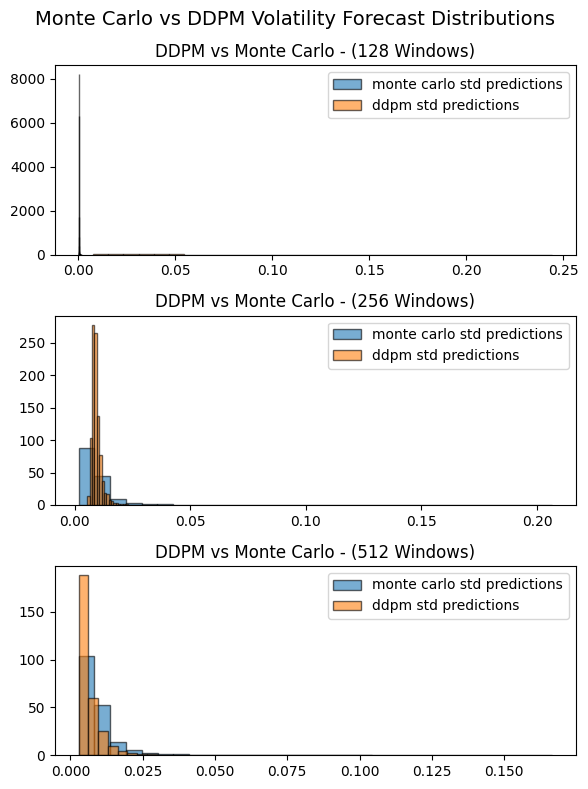

In [38]:
mc_preds_128_flattened = mc_preds_128.reshape(-1)
mc_preds_256_flattened = mc_preds_256.reshape(-1)
mc_preds_512_flattened = mc_preds_512.reshape(-1)

syn_preds_128_flattened = syn_preds_windows_128.reshape(-1)
syn_preds_256_flattened = syn_preds_windows_256.reshape(-1)
syn_preds_512_flattened = syn_preds_windows_512.reshape(-1)

bins = 30

fig, ax = plt.subplots(3, figsize=(6, 8))
ax[0].hist(mc_preds_128_flattened, bins, alpha=0.6, label="monte carlo std predictions", density=True, edgecolor="black", linewidth=1)
ax[0].hist(syn_preds_128_flattened, bins, alpha=0.6, label="ddpm std predictions", density=True, edgecolor="black", linewidth=1)
ax[0].set_title("DDPM vs Monte Carlo - (128 Windows)")
ax[0].legend()

ax[1].hist(mc_preds_256_flattened, bins, alpha=0.6, label="monte carlo std predictions", density=True, edgecolor="black", linewidth=1)
ax[1].hist(syn_preds_256_flattened, bins, alpha=0.6, label="ddpm std predictions", density=True, edgecolor="black", linewidth=1)
ax[1].set_title("DDPM vs Monte Carlo - (256 Windows)")
ax[1].legend()

ax[2].hist(mc_preds_512_flattened, bins, alpha=0.6, label="monte carlo std predictions", density=True, edgecolor="black", linewidth=1)
ax[2].hist(syn_preds_512_flattened, bins, alpha=0.6, label="ddpm std predictions", density=True, edgecolor="black", linewidth=1)
ax[2].set_title("DDPM vs Monte Carlo - (512 Windows)")
ax[2].legend()

plt.suptitle("Monte Carlo vs DDPM Volatility Forecast Distributions", fontsize=14)
plt.tight_layout()
plt.show()

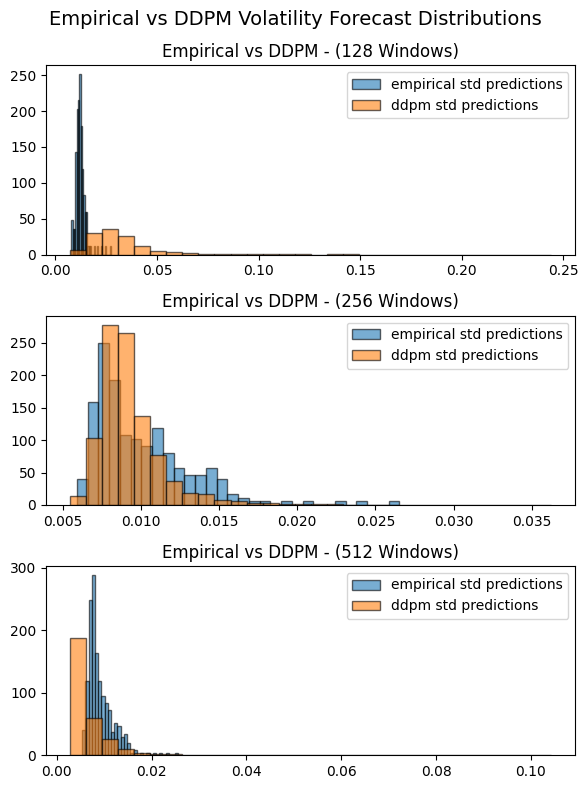

In [39]:
bins = 30

fig, ax = plt.subplots(3, figsize=(6, 8))
ax[0].hist(emp_preds_128, bins, alpha=0.6, label="empirical std predictions", density=True, edgecolor="black", linewidth=1)
ax[0].hist(syn_preds_128_flattened, bins, alpha=0.6, label="ddpm std predictions", density=True, edgecolor="black", linewidth=1)
ax[0].set_title("Empirical vs DDPM - (128 Windows)")
ax[0].legend()

ax[1].hist(emp_preds_256, bins, alpha=0.6, label="empirical std predictions", density=True, edgecolor="black", linewidth=1)
ax[1].hist(syn_preds_256_flattened, bins, alpha=0.6, label="ddpm std predictions", density=True, edgecolor="black", linewidth=1)
ax[1].set_title("Empirical vs DDPM - (256 Windows)")
ax[1].legend()

ax[2].hist(emp_preds_512, bins, alpha=0.6, label="empirical std predictions", density=True, edgecolor="black", linewidth=1)
ax[2].hist(syn_preds_512_flattened, bins, alpha=0.6, label="ddpm std predictions", density=True, edgecolor="black", linewidth=1)
ax[2].set_title("Empirical vs DDPM - (512 Windows)")
ax[2].legend()

plt.suptitle("Empirical vs DDPM Volatility Forecast Distributions", fontsize=14)
plt.tight_layout()
plt.show()

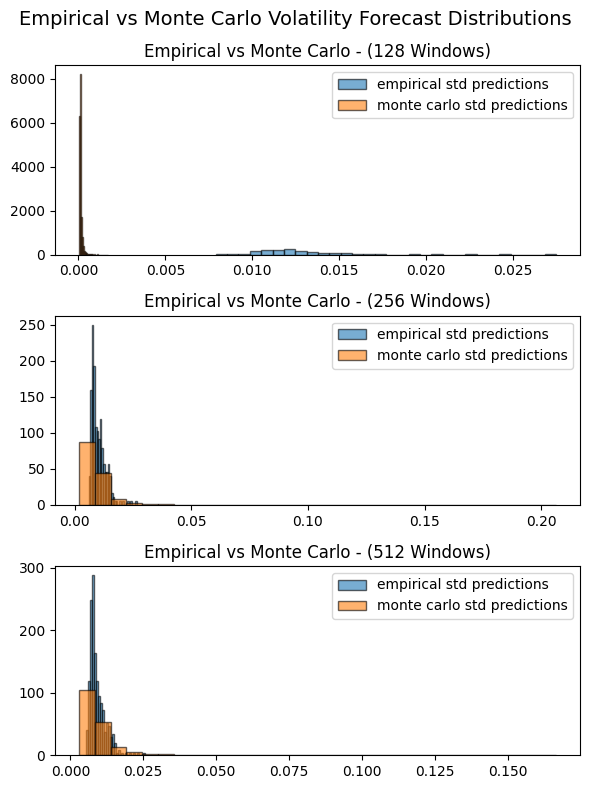

In [40]:
bins = 30

fig, ax = plt.subplots(3, figsize=(6, 8))
ax[0].hist(emp_preds_128, bins, alpha=0.6, label="empirical std predictions", density=True, edgecolor="black", linewidth=1)
ax[0].hist(mc_preds_128_flattened, bins, alpha=0.6, label="monte carlo std predictions", density=True, edgecolor="black", linewidth=1)
ax[0].set_title("Empirical vs Monte Carlo - (128 Windows)")
ax[0].legend()

ax[1].hist(emp_preds_256, bins, alpha=0.6, label="empirical std predictions", density=True, edgecolor="black", linewidth=1)
ax[1].hist(mc_preds_256_flattened, bins, alpha=0.6, label="monte carlo std predictions", density=True, edgecolor="black", linewidth=1)
ax[1].set_title("Empirical vs Monte Carlo - (256 Windows)")
ax[1].legend()

ax[2].hist(emp_preds_512, bins, alpha=0.6, label="empirical std predictions", density=True, edgecolor="black", linewidth=1)
ax[2].hist(mc_preds_512_flattened, bins, alpha=0.6, label="monte carlo std predictions", density=True, edgecolor="black", linewidth=1)
ax[2].set_title("Empirical vs Monte Carlo - (512 Windows)")
ax[2].legend()

plt.suptitle("Empirical vs Monte Carlo Volatility Forecast Distributions", fontsize=14)
plt.tight_layout()
plt.show()

### Var Analysis